<a href="https://colab.research.google.com/github/yannn2505/Belajar-OpenCV-ObjectDetection_Pertemuan7/blob/main/7_3_pretrained_faster_rcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 7.3 Pretrained Faster R-CNN Model

⚠️⚠️⚠️ *Silakan buka notebook ini di Google Colab* dengan klik link berikut ⚠️⚠️⚠️<br><br>
<a href="https://colab.research.google.com/github/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/7.3%20pretrained_faster_rcnn.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><br><br><br>

- Klik tombol `Connect` di bagian kanan atas Google Colab untuk menghubungkan runtime,<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/cl-connect-gpu.png?raw=1" width="250px">

- Setelah berhasil terhubung, tampilan akan berubah seperti berikut yang menandakan notebook sudah siap digunakan untuk menjalankan kode,<br>
<img src="https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/blob/main/Pertemuan%207/resource/cl-connect-gpu-success.png?raw=1" width="250px">

- Dengan menggunakan Google Colab, kita dapat menjalankan model <font color="orange">Faster R-CNN</font> tanpa perlu instalasi di perangkat lokal serta dapat memanfaatkan GPU untuk mempercepat proses inferensi.

- Check GPU connected into Colab environment is active

In [ ]:
!nvidia-smi

Wed Apr 22 07:12:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2

- Define COCO Class Names (91 class)

In [ ]:
COCO_CLASS_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

- Load image Sample

In [ ]:
# Download gambar contoh dari repository
import urllib

url, filename = (
    "https://github.com/Muhammad-Yunus/Belajar-OpenCV-ObjectDetection/raw/main/Pertemuan%207/image2.jpg",
    "image2.jpg"
)

try:
    # Cara lama (kompatibel untuk beberapa versi Python)
    urllib.URLopener().retrieve(url, filename)
except:
    # Cara umum untuk Python versi baru
    urllib.request.urlretrieve(url, filename)

# Penjelasan:
# - url → alamat gambar di internet
# - filename → nama file saat disimpan di lokal
# - try-except → memastikan kode tetap jalan di berbagai versi Python
# - Gambar ini akan digunakan sebagai input untuk model Faster R-CNN

In [ ]:
# Menampilkan gambar menggunakan matplotlib
def imshow(image, isBGR=True):
    if isBGR:
        # OpenCV membaca gambar dalam format BGR
        # matplotlib menggunakan format RGB → perlu dikonversi
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)   # menampilkan gambar
    plt.axis("off")     # menghilangkan axis agar lebih rapi

# Penjelasan:
# - Fungsi ini digunakan untuk menampilkan gambar dengan benar
# - isBGR=True → otomatis konversi warna dari OpenCV ke matplotlib
# - plt.axis("off") → tampilan lebih bersih tanpa koordinat

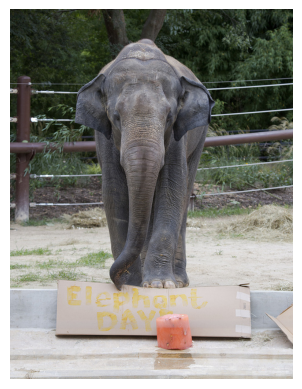

In [ ]:
# Load gambar dan preprocessing
image_path = 'image2.jpg'  # path gambar
image = cv2.imread(image_path)  # membaca gambar (format BGR)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# konversi ke RGB agar sesuai dengan model dan matplotlib

# Convert image ke tensor (format PyTorch)
input_tensor = torch.tensor(image).float().permute(2, 0, 1).unsqueeze(0)

# Penjelasan:
# - torch.tensor(image) → ubah gambar jadi tensor
# - .float() → ubah ke tipe float
# - .permute(2,0,1) → ubah (H,W,C) jadi (C,H,W)
# - .unsqueeze(0) → tambah dimensi batch → (1,C,H,W)

input_tensor = input_tensor / 255.0
# normalisasi pixel dari 0-255 → 0-1

# Tampilkan gambar
imshow(image, isBGR=False)
# isBGR=False karena gambar sudah RGB

- Memuat model <font color="orange">Faster R-CNN</font> pretrained dengan backbone <font color="orange">ResNet-50</font>
    - Model pretrained ini disediakan oleh <font color="orange">Torchvision</font>, sehingga dapat langsung digunakan tanpa perlu melatih dari awal.
    - Backbone <font color="orange">ResNet-50</font> digunakan untuk mengekstrak feature map dari gambar, yang kemudian diproses oleh <font color="orange">Region Proposal Network (RPN)</font> dan tahap deteksi.
    - Model ini sudah dilatih pada dataset besar seperti COCO, sehingga mampu mendeteksi berbagai objek secara umum.

In [ ]:
# Load the Faster R-CNN model pre-trained on COCO dataset from Torch Vision
model = fasterrcnn_resnet50_fpn_v2(
            weights='DEFAULT'
        )

# Set the model to evaluation mode
model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 179MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [ ]:
# Perform inference (prediksi objek)
with torch.no_grad():
    predictions = model(input_tensor)

# Penjelasan:
# - torch.no_grad() → menonaktifkan gradient (lebih cepat & hemat memori)
# - model(input_tensor) → menjalankan deteksi objek
# - output disimpan di variabel predictions

# Menampilkan hasil prediksi
print(predictions)

# Penjelasan:
# - predictions berisi hasil deteksi berupa:
#   - boxes  → koordinat bounding box (x_min, y_min, x_max, y_max)
#   - labels → kelas objek (misalnya person, car, dll)
#   - scores → tingkat kepercayaan model (confidence)

[{'boxes': tensor([[1.0915e+02, 4.8333e+01, 3.5527e+02, 4.8632e+02],
        [2.5246e+02, 5.2453e+02, 3.1601e+02, 5.8932e+02],
        [4.4126e+02, 5.0504e+02, 4.9000e+02, 5.8572e+02],
        [8.5272e+01, 4.7197e+02, 4.1631e+02, 5.7266e+02],
        [4.3407e+02, 4.9949e+02, 4.8954e+02, 5.8186e+02],
        [3.6036e+01, 4.7803e+02, 4.5504e+02, 6.1105e+02],
        [2.5318e+02, 5.2450e+02, 3.1695e+02, 5.9178e+02],
        [2.5196e+02, 5.2476e+02, 3.1702e+02, 5.9136e+02],
        [2.5219e+02, 5.2458e+02, 3.1784e+02, 5.9015e+02],
        [8.5891e+01, 4.7375e+02, 4.1498e+02, 5.7081e+02],
        [1.2218e+01, 4.9216e+02, 4.8644e+02, 6.2480e+02],
        [8.1453e+01, 4.6886e+02, 4.1805e+02, 5.6970e+02],
        [4.3494e+02, 5.0523e+02, 4.8971e+02, 5.8188e+02],
        [6.0394e-02, 1.3677e+02, 1.2519e+01, 1.4598e+02],
        [8.4989e+01, 4.7196e+02, 4.1567e+02, 5.7010e+02],
        [8.9545e+01, 4.7414e+02, 4.1295e+02, 5.6986e+02]]), 'labels': tensor([22, 33, 28, 33,  9, 15, 57, 61, 47, 73, 6

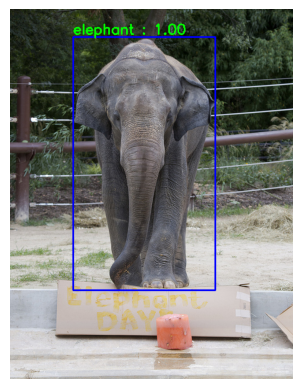

In [ ]:
# Filter predictions with a threshold score
threshold = 0.89
mask = predictions[0]['scores'] > threshold
filtered_boxes = predictions[0]['boxes'][mask]
filtered_scores = predictions[0]['scores'][mask]
filtered_labels = predictions[0]['labels'][mask]


# Draw bounding boxes, labels, and confidence scores on the image
image_with_box = image.copy()

for box, score, label in zip(filtered_boxes, filtered_scores, filtered_labels):
    x_min, y_min, x_max, y_max = map(int, box)  # Extract and convert box coordinates to int
    image_with_box = cv2.rectangle(
                            image_with_box,
                            (x_min, y_min),
                            (x_max, y_max),
                            color=(0, 0, 255),
                            thickness=2
                            )

    text = f"{COCO_CLASS_NAMES[label.item()]} : {score.item():.2f}"
    image_with_box = cv2.putText(
                            image_with_box,
                            text,
                            (x_min, y_min - 5),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.8,
                            (0, 255, 0),
                            2
                            )

imshow(image_with_box, isBGR=False)
